In [1]:
%cd ../../

/Users/macos/Uni/1st_year/period_2/IntroML/homework


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns

In [3]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

In [4]:
path_df = "E1/data/p1.csv"

df_p1 = pd.read_csv(path_df)

In [5]:
df_p1.head()

,id,SMILES,InChIKey,pSat_Pa,ChemPot_kJmol,FreeEnergy_kJmol,HeatOfVap_kJmol,MW,NumOfAtoms,NumOfC,...,ester,ether (alicyclic),nitrate,nitro,aromatic hydroxyl,carbonylperoxynitrate,peroxide,hydroperoxide,carbonylperoxyacid,nitroester
0,100809,C12OOC(C1(O)C)C(OO)C(O)C2(ON(=O)(=O)),TXLAJLFBOQXVTN-UHFFFAOYSA-N,0.000010,4.269730,-2.639635e+06,127.665681,253.043381,28,7,...,0,0,1,0,0,0,1,1,0,0
1,11712,C(=O)(O)C(O)C(O)C(OO)C(=O),QXQIFULVHGTXBH-UHFFFAOYSA-N,0.000003,5.474680,-1.896203e+06,129.070835,180.027003,20,5,...,0,0,0,0,0,0,0,1,0,0
2,32538,C(=O)(OO)C(ON(=O)(=O))C(OO)C1(C)OC1(O)C(=O)(OO...,YVVINRLCMZARIG-UHFFFAOYSA-N,0.000146,16.510064,-3.963845e+06,118.474897,359.992468,32,7,...,0,1,1,0,0,1,0,1,1,0
3,152549,CC(OO)(C)C(ON(=O)(=O))(C(=O)(OO))C(=O)C(O),UWLIEVAXQQOHNO-UHFFFAOYSA-N,0.000010,10.097080,-2.837243e+06,124.455256,269.038296,29,7,...,0,0,1,0,0,0,0,1,1,0
4,146216,CC(ON(=O)(=O))C1OOC(ON(=O)(=O))(C1(=O))C(=O)(O),ZSDGMDQNNAXLCT-UHFFFAOYSA-N,0.014830,14.133175,-3.070631e+06,96.152881,281.997159,25,6,...,0,0,2,0,0,0,1,0,0,0


## Task a

In [6]:
df_p1 = df_p1.drop(columns=["id", "SMILES", "InChIKey"])

df_p1.head()

,pSat_Pa,ChemPot_kJmol,FreeEnergy_kJmol,HeatOfVap_kJmol,MW,NumOfAtoms,NumOfC,NumOfO,NumOfN,NumHBondDonors,...,ester,ether (alicyclic),nitrate,nitro,aromatic hydroxyl,carbonylperoxynitrate,peroxide,hydroperoxide,carbonylperoxyacid,nitroester
0,0.000010,4.269730,-2.639635e+06,127.665681,253.043381,28,7,9,1,3,...,0,0,1,0,0,0,1,1,0,0
1,0.000003,5.474680,-1.896203e+06,129.070835,180.027003,20,5,7,0,4,...,0,0,0,0,0,0,0,1,0,0
2,0.000146,16.510064,-3.963845e+06,118.474897,359.992468,32,7,15,2,3,...,0,1,1,0,0,1,0,1,1,0
3,0.000010,10.097080,-2.837243e+06,124.455256,269.038296,29,7,10,1,3,...,0,0,1,0,0,0,0,1,1,0
4,0.014830,14.133175,-3.070631e+06,96.152881,281.997159,25,6,11,2,1,...,0,0,2,0,0,0,1,0,0,0


## Task b

In [7]:
df_p1[['pSat_Pa','NumOfConf','ChemPot_kJmol']].describe()

,pSat_Pa,NumOfConf,ChemPot_kJmol
count,4.000000e+02,400.000000,400.000000
mean,2.961988e+00,223.497500,12.434427
std,3.353178e+01,190.915391,4.778872
min,2.458865e-10,2.000000,-3.160050
25%,4.926186e-06,73.250000,9.722915
50%,1.210795e-04,172.500000,12.780677
75%,2.287152e-03,324.250000,15.658871
max,5.628970e+02,1058.000000,28.095686


## Task c

In [8]:
chem = df_p1['ChemPot_kJmol'].values

print(f"mean: {chem.mean()}")
print(f"std: {chem.std()}")

mean: 12.434427089600002
std: 4.772894849454553


## Task d

In [9]:
pSat_Pa = df_p1['pSat_Pa']
num_cof = df_p1['NumOfConf']

/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'NumOfConf')

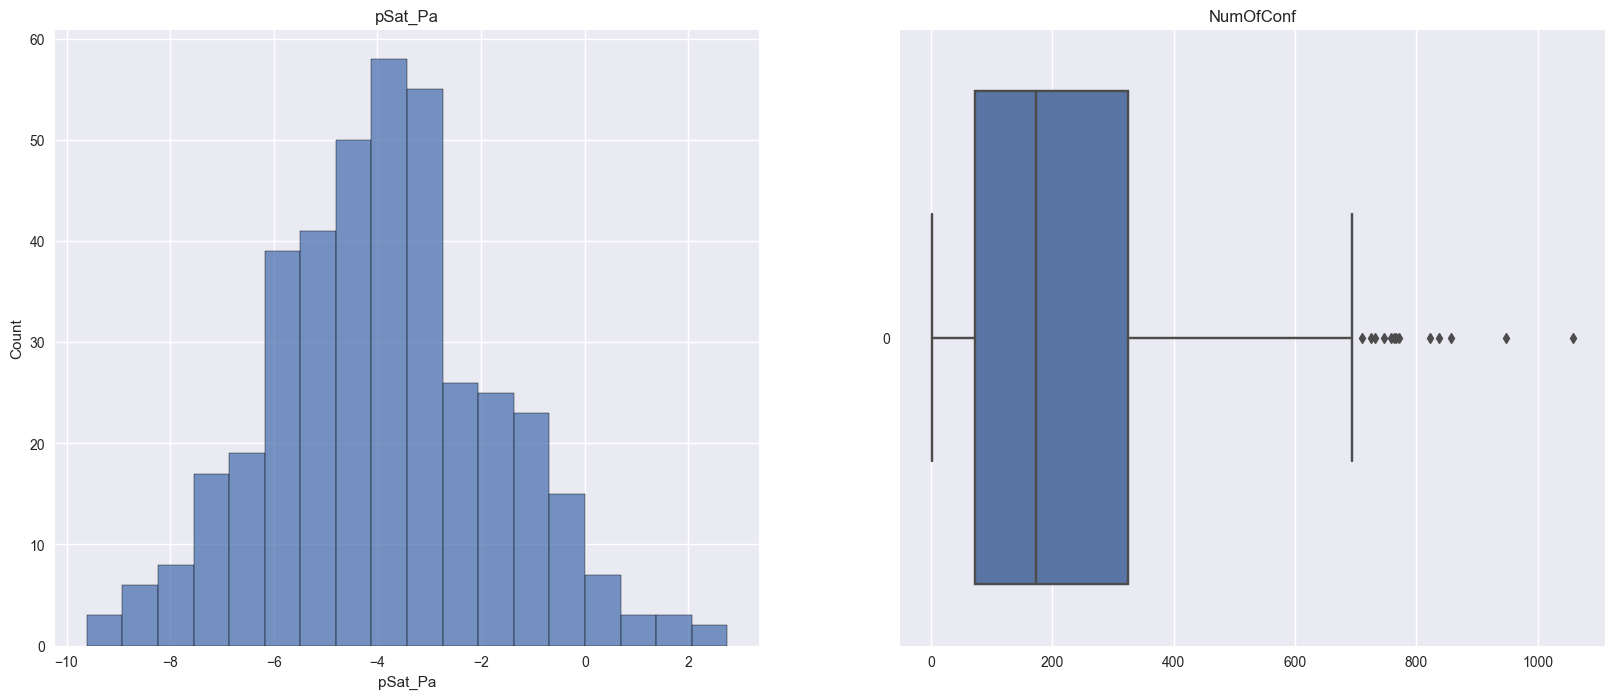

In [20]:
fig = plt.figure(figsize=(20, 8))

ax = fig.add_subplot(121)
sns.histplot(np.log10(pSat_Pa), ax=ax)
ax.set_title("pSat_Pa")

ax = fig.add_subplot(122)
sns.boxplot(num_cof, ax=ax, orient='h')
ax.set_title("NumOfConf")

In [21]:
df_scatter = df_p1[["MW", "HeatOfVap_kJmol", "FreeEnergy_kJmol"]]

df_scatter.head()

,MW,HeatOfVap_kJmol,FreeEnergy_kJmol
0,253.043381,127.665681,-2.639635e+06
1,180.027003,129.070835,-1.896203e+06
2,359.992468,118.474897,-3.963845e+06
3,269.038296,124.455256,-2.837243e+06
4,281.997159,96.152881,-3.070631e+06


/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a 

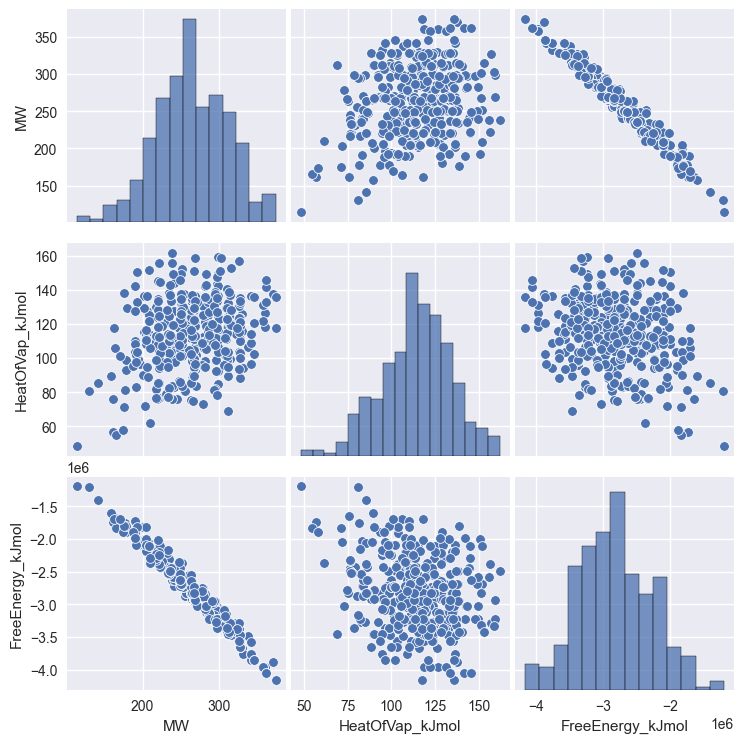

In [27]:

sns.pairplot(df_scatter)